<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_1697/1366138731.py:37: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(mags[:150], 'o-', label=f'$\epsilon$ = {eps}', color=color, markersize=3, alpha=0.8)


正在计算 epsilon = 0.001...
正在计算 epsilon = 0.005...
正在计算 epsilon = 0.01...
正在计算 epsilon = 0.03...


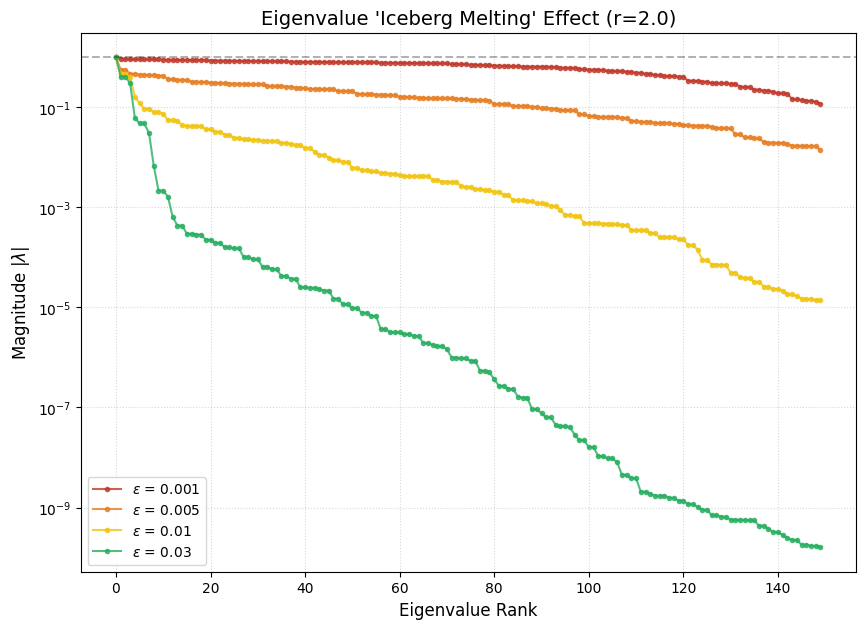

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def compute_mags_with_epsilon(r, N, eps):
    edges = np.linspace(-1, 1, N + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    P = np.zeros((N, N))
    
    for j in range(N):
        x_next = 1 - r * (centers[j]**2)
        if -1.1 <= x_next <= 1.1:
            # 距离计算
            dist = np.abs(centers - x_next)
            # 加入噪声 eps
            if eps > 0:
                kernel = np.exp(-dist**2 / (2 * eps**2))
                P[:, j] = kernel / kernel.sum()
            else:
                # 无噪声情况（乌拉姆原始方法）
                i = np.searchsorted(edges, x_next) - 1
                if 0 <= i < N: P[i, j] = 1.0
                
    eigvals = np.linalg.eigvals(P)
    return np.sort(np.abs(eigvals))[::-1]

# 参数设置
r_val = 2.0  # 选完全混沌态效果最明显
N_bins = 600
epsilons = [0.001, 0.005, 0.01, 0.03]
colors = ['#C0392B', '#E67E22', '#F1C40F', '#27AE60']

plt.figure(figsize=(10, 7))

for eps, color in zip(epsilons, colors):
    print(f"正在计算 epsilon = {eps}...")
    mags = compute_mags_with_epsilon(r_val, N_bins, eps)
    plt.plot(mags[:150], 'o-', label=f'$\epsilon$ = {eps}', color=color, markersize=3, alpha=0.8)

plt.axhline(y=1.0, color='k', linestyle='--', alpha=0.3)
plt.title(f"Eigenvalue 'Iceberg Melting' Effect (r={r_val})", fontsize=14)
plt.xlabel("Eigenvalue Rank", fontsize=12)
plt.ylabel(r"Magnitude $|\lambda|$", fontsize=12)
plt.yscale('log') # 使用对数坐标看衰减更清晰
plt.grid(which='both', linestyle=':', alpha=0.5)
plt.legend()
plt.show()